In [29]:
import pytensor
# Tell PyTensor to use a more robust (but slower) backend that avoids C compilation issues.
# Place this in the first cell of your notebook.
# pytensor.config.optimizer = 'fast_compile'

import pandas as pd
import numpy as np
import pymc as pm
import scipy.stats as stats
import arviz as az
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, minmax_scale

from gurobipy import *
import pytensor.tensor as pt

import joblib



## Get player details


In [30]:
# %run '../FPL predictors/Fantasy Go/map FGo to FPL.ipynb'

In [ ]:
players_preds = pd.read_csv('./../FPL predictors/with new features/models/preds/players_preds_36.csv', index_col=0)
players_preds['efficiency'] = players_preds['xP_preds'] / players_preds['value']

# Filter to work with only a limited number of players with good xP_pred:value
eff_threshold = players_preds.groupby('position')['efficiency'].quantile(0.30)
filtered_players = players_preds[
    players_preds['efficiency'] >= players_preds['position'].map(eff_threshold)
]

optimizer_pool = filtered_players.copy()

fpl_teams_ids = pd.read_csv('../FPL predictors/with new features/data/fpl_names_24_25.csv')

optimizer_pool = optimizer_pool.rename(columns={'FPL_Name': 'fpl_name', 'Understat_Name': 'understat_name'})
# Add fpl_id to player_preds
optimizer_pool = optimizer_pool.merge(fpl_teams_ids, left_on='fpl_name', right_on='FPL_Name', how='left')
optimizer_pool.dropna(subset=['FPL_ID'], inplace=True)

optimizer_pool = optimizer_pool.drop(['event', 'understat_name', 'fpl_name', 'FPL_ID','FPL_Name', 'team', 'xG_preds', 'xA_preds', 'cs_preds', 'y_preds', 'saves_preds', 'xgc_preds', 'h_team', 'a_team','was_home', 'assists_x'], axis=1)
player_cols = optimizer_pool.columns.tolist()

In [ ]:
common_features = [
    'expected_goals_conceded_rolling_5', 'influence_5_ewm', 'lose_prob', 'transfers_in_5_ewm', 'xA_5_ewm', 'percentage_net_transfers_5_ewm', 'xGBuildup_3_ewm',
    'xGBuildup_5_ewm', 'ict_index_rolling_5', 'assists_3_ewm', 'ownership_change_rolling_3', 'value', 'xP_5_ewm', 'selected_by_percent_5_ewm',
    'selected_by_percent_rolling_1', 'win_prob', 'influence_rolling_5', 'selected_by_percent', 'npg_3_ewm', 'minutes_rolling_5','selected_by_percent_rolling_5',
    'npxG_rolling_3', 'expected_goals_conceded_5_ewm', 'xGBuildup_rolling_3', 'transfers_in_rolling_1', 'value_rolling_5',
    'expected_goal_involvements_rolling_1', 'expected_goals_conceded_rolling_1', 'xGChain_rolling_1', 'ownership_change', 'influence_3_ewm', 'transfers_out',
    'xP_rolling_1', 'xP_3_ewm', 'selected_rolling_5', 'transfers_out_rolling_1', 'expected_goals_conceded_3_ewm', 'percentage_net_transfers_3_ewm',
    'xGChain_rolling_3', 'xGBuildup_rolling_5', 'xGChain_rolling_5', 'goals_conceded_5_ewm', 'xP_rolling_3', 'percentage_net_transfers', 'yellow_cards_5_ewm',
    'npxG_rolling_5', 'transfers_out_rolling_5', 'xGChain_5_ewm', 'yellow_cards_3_ewm', 'creativity_rolling_1', 'ict_index_rolling_3', 'transfers_in_rolling_3',
    'pts_bps_3_ewm', 'influence_rolling_1', 'xA_rolling_5', 'ownership_change_rolling_1', 'transfers_in', 'clean_sheets_3_ewm', 'selected',
    'expected_goals_conceded_rolling_3', 'pts_bps_rolling_3', 'draw_prob', 'xA_rolling_3', 'xGBuildup_rolling_1', 'ownership_change_3_ewm',
    'percentage_net_transfers_rolling_5', 'ict_index_rolling_1', 'ownership_change_rolling_5', 'clean_sheets_5_ewm', 'creativity_rolling_3',
    'percentage_net_transfers_rolling_3', 'transfers_out_5_ewm', 'transfers_in_3_ewm', 'creativity_rolling_5', 'transfers_in_rolling_5',
    'goals_conceded_3_ewm', 'pts_bps_rolling_1', 'percentage_net_transfers_rolling_1', 'influence_rolling_3', 'pts_bps_5_ewm', 'pts_bps_rolling_5',
    'team_a_difficulty', 'team_h_difficulty'
]

common_features_gk = [
    'expected_goals_conceded_rolling_5', 'influence_5_ewm', 'lose_prob', 'transfers_in_5_ewm', 'xA_5_ewm', 'percentage_net_transfers_5_ewm', 'xGBuildup_3_ewm',
    'xGBuildup_5_ewm', 'ict_index_rolling_5', 'assists_3_ewm', 'ownership_change_rolling_3', 'value', 'xP_5_ewm', 'selected_by_percent_5_ewm',
    'selected_by_percent_rolling_1', 'win_prob', 'influence_rolling_5', 'selected_by_percent', 'npg_3_ewm', 'minutes_rolling_5','selected_by_percent_rolling_5',
    'npxG_rolling_3', 'expected_goals_conceded_5_ewm', 'xGBuildup_rolling_3', 'transfers_in_rolling_1', 'value_rolling_5',
    'expected_goal_involvements_rolling_1', 'expected_goals_conceded_rolling_1', 'xGChain_rolling_1', 'ownership_change', 'influence_3_ewm', 'transfers_out',
    'xP_rolling_1', 'xP_3_ewm', 'selected_rolling_5', 'transfers_out_rolling_1', 'expected_goals_conceded_3_ewm', 'percentage_net_transfers_3_ewm',
    'xGChain_rolling_3', 'xGBuildup_rolling_5', 'xGChain_rolling_5', 'goals_conceded_5_ewm', 'xP_rolling_3', 'percentage_net_transfers', 'yellow_cards_5_ewm',
    'npxG_rolling_5', 'transfers_out_rolling_5', 'xGChain_5_ewm', 'yellow_cards_3_ewm', 'creativity_rolling_1', 'ict_index_rolling_3', 'transfers_in_rolling_3',
    'pts_bps_3_ewm', 'influence_rolling_1', 'xA_rolling_5', 'ownership_change_rolling_1', 'transfers_in', 'clean_sheets_3_ewm', 'selected',
    'expected_goals_conceded_rolling_3', 'pts_bps_rolling_3', 'draw_prob', 'xA_rolling_3', 'xGBuildup_rolling_1', 'ownership_change_3_ewm',
    'percentage_net_transfers_rolling_5', 'ict_index_rolling_1', 'ownership_change_rolling_5', 'clean_sheets_5_ewm', 'creativity_rolling_3',
    'percentage_net_transfers_rolling_3', 'transfers_out_5_ewm', 'transfers_in_3_ewm', 'creativity_rolling_5', 'transfers_in_rolling_5',
    'goals_conceded_3_ewm', 'pts_bps_rolling_1', 'percentage_net_transfers_rolling_1', 'influence_rolling_3', 'pts_bps_5_ewm', 'pts_bps_rolling_5',
    'team_a_difficulty', 'team_h_difficulty',
]

data_cols_all = ['clean_sheets',  'creativity', 'ict_index',  'influence',  'selected',  'threat',  'transfers_balance', 'transfers_in',  'transfers_out',  'value',
                 'team_h_difficulty',  'team_a_difficulty', 'ownership_change',  'percenatge_net_transfers', 'whh',  'whd',  'wha', 'xP','ownership_percent',

            'clean_sheets_1',  'expected_assists_1',  'expected_goal_involvements_1',
            'expected_goals_1',  'expected_goals_conceded_1',  'goals_conceded_1',  'goals_scored_1',  'ict_index_1',  'influence_1',
            'creativity_1',  'threat_1',  'minutes_1',  'own_goals_1',  'penalties_missed_1',  'penalties_saved_1',  'red_cards_1',
            'yellow_cards_1',  'saves_1',  'starts_1',  'team_a_score_1',  'team_h_score_1',  'total_points_1',  'goals_1',  'shots_1',
            'xG_1',  'xA_1',  'assists_x_1',  'key_passes_1',  'npg_1',  'npxG_1',  'xGChain_1',  'xGBuildup_1',  'xP_1',

            'clean_sheets_3',  'expected_assists_3',  'expected_goal_involvements_3',  'expected_goals_3',  'expected_goals_conceded_3',
            'goals_conceded_3',  'goals_scored_3',  'ict_index_3',  'influence_3',  'creativity_3',  'threat_3',  'minutes_3',  'own_goals_3',
            'penalties_missed_3',  'penalties_saved_3',  'red_cards_3',  'yellow_cards_3',  'saves_3',  'starts_3',  'team_a_score_3',
            'team_h_score_3',  'total_points_3',  'goals_3',  'shots_3',  'xG_3',  'xA_3',  'assists_x_3', 'key_passes_3',
            'npg_3',  'npxG_3',  'xGChain_3',  'xGBuildup_3',  'xP_3',

            'clean_sheets_5',  'expected_assists_5',  'expected_goal_involvements_5',  'expected_goals_5',  'expected_goals_conceded_5',  'goals_conceded_5',
            'goals_scored_5',  'ict_index_5',  'influence_5',  'creativity_5',  'threat_5',  'minutes_5',  'own_goals_5',  'penalties_missed_5',  'penalties_saved_5',
            'red_cards_5',  'yellow_cards_5',  'saves_5',  'starts_5',  'team_a_score_5',  'team_h_score_5',  'total_points_5',  'goals_5',  'shots_5',  'xG_5',  'xA_5',
            'assists_x_5', 'key_passes_5',  'npg_5',  'npxG_5',  'xGChain_5',  'xGBuildup_5',  'xP_5', 'xP_cost'
        ]

data_cols_gk = [
                'clean_sheets', 'creativity', 'ict_index', 'influence', 'selected', 'threat', 'transfers_balance', 'transfers_in', 'transfers_out', 'value',
                'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers', 'whh',  'whd',  'wha', 'xP','ownership_percent',

                'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1',
                'penalties_saved_1', 'red_cards_1', 'yellow_cards_1', 'saves_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1',  'goals_1', 'xG_1',
                'key_passes_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

                'clean_sheets_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3',
                'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'key_passes_3',
                'xGChain_3', 'xGBuildup_3', 'xP_3',

                'clean_sheets_5', 'expected_goals_conceded_5',  'goals_conceded_5', 'ict_index_5',  'influence_5',  'creativity_5',  'threat_5',  'minutes_5',  'own_goals_5',
                'penalties_saved_5', 'red_cards_5',  'yellow_cards_5',  'saves_5',  'starts_5',  'team_a_score_5',  'team_h_score_5', 'total_points_5',  'goals_5',  'shots_5',
                'key_passes_5', 'xGChain_5',  'xGBuildup_5', 'xP_5', 'xP_cost'
                ]

data_cols = [
                'clean_sheets', 'creativity', 'ict_index', 'influence', 'selected', 'threat', 'transfers_balance', 'transfers_in', 'transfers_out', 'value',
                'team_h_difficulty',  'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers', 'whh', 'whd', 'wha', 'xP', 'ownership_percent',

                'clean_sheets_1', 'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1', 'expected_goals_conceded_1', 'goals_conceded_1',
                'goals_scored_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'red_cards_1', 'yellow_cards_1', 'saves_1', 'starts_1',
                'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'key_passes_1', 'npg_1', 'npxG_1',
                'xGChain_1', 'xGBuildup_1', 'xP_1',

                'clean_sheets_3', 'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3',
                'goals_scored_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
                'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'key_passes_3', 'npg_3', 'npxG_3',
                'xGChain_3', 'xGBuildup_3', 'xP_3',

                'clean_sheets_5', 'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5',
                'goals_scored_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
                'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'key_passes_5', 'npg_5', 'npxG_5',
                'xGChain_5', 'xGBuildup_5', 'xP_5', 'xP_cost'
        ]

feats_cols = ["selected", "transfers_in", "transfers_out", "value", "xP_5", "total_points_1", "team_h_difficulty", "team_a_difficulty", "ownership_percent"]


feats_cols_gk = [
                'ownership_change', 'ownership_change_1_ewm', 'ownership_change_5_ewm', 'transfers_in', 'transfers_out', 'value', 'team_h_difficulty',
                'team_a_difficulty','pts_bps_1_ewm', 'pts_bps_5_ewm', 'xP_1_ewm', 'xP_5_ewm', 'minutes_1_ewm', 'minutes_5_ewm', 'percentage_net_transfers',
                'percentage_net_transfers_1_ewm', 'percentage_net_transfers_5_ewm', 'selected_by_percent', 'selected_by_percent_1_ewm',
                'selected_by_percent_5_ewm','expected_goals_conceded_1_ewm', 'expected_goals_conceded_5_ewm', 'goals_conceded_1_ewm', 'goals_conceded_5_ewm',
                'clean_sheets_1_ewm', 'clean_sheets_5_ewm', 'saves_1_ewm', 'saves_5_ewm',
]

feats_cols_def = [
                'ownership_change', 'ownership_change_1_ewm', 'ownership_change_5_ewm', 'transfers_in', 'transfers_out', 'value', 'team_h_difficulty',
                'team_a_difficulty','pts_bps_1_ewm', 'pts_bps_5_ewm', 'xP_1_ewm', 'xP_5_ewm', 'minutes_1_ewm', 'minutes_5_ewm', 'percentage_net_transfers',
                'percentage_net_transfers_1_ewm', 'percentage_net_transfers_5_ewm', 'selected_by_percent', 'selected_by_percent_1_ewm',
                'selected_by_percent_5_ewm','expected_goals_conceded_1_ewm', 'expected_goals_conceded_5_ewm', 'goals_conceded_1_ewm', 'goals_conceded_5_ewm',
                 'clean_sheets_1_ewm', 'clean_sheets_5_ewm', 'xG_1_ewm', 'xG_5_ewm', 'xA_1_ewm', 'xA_5_ewm',
]
feats_cols_mid = [
                'ownership_change', 'ownership_change_1_ewm', 'ownership_change_5_ewm', 'transfers_in', 'transfers_out', 'value', 'team_h_difficulty',
                'team_a_difficulty','pts_bps_1_ewm', 'pts_bps_5_ewm', 'xP_1_ewm', 'xP_5_ewm', 'minutes_1_ewm', 'minutes_5_ewm', 'percentage_net_transfers',
                'percentage_net_transfers_1_ewm', 'percentage_net_transfers_5_ewm', 'selected_by_percent', 'selected_by_percent_1_ewm',
                'selected_by_percent_5_ewm', 'npxG_5_ewm', 'npxG_1_ewm',  'xG_1_ewm', 'xG_5_ewm', 'xA_1_ewm', 'xA_5_ewm',
]

feats_cols_fwd = [
                'ownership_change', 'ownership_change_1_ewm', 'ownership_change_5_ewm', 'transfers_in', 'transfers_out', 'value', 'team_h_difficulty',
                'team_a_difficulty','pts_bps_1_ewm', 'pts_bps_5_ewm', 'xP_1_ewm', 'xP_5_ewm', 'minutes_1_ewm', 'minutes_5_ewm', 'percentage_net_transfers',
                'percentage_net_transfers_1_ewm', 'percentage_net_transfers_5_ewm', 'selected_by_percent', 'selected_by_percent_1_ewm',
                'selected_by_percent_5_ewm', 'npxG_5_ewm', 'npxG_1_ewm',  'xG_1_ewm', 'xG_5_ewm', 'xA_1_ewm', 'xA_5_ewm',
]
FPL_teams_23_24 = ['West Ham United', 'Manchester United', 'Everton', 'Bournemouth',
       'Brighton and Hove Albion', 'Crystal Palace', 'Fulham', 'Luton',
       'Tottenham Hotspur', 'Newcastle United', 'Aston Villa',
       'Liverpool', 'Chelsea', 'Sheffield United', 'Nottingham Forest',
       'Burnley', 'Arsenal', 'Manchester City', 'Wolverhampton Wanderers',
       'Brentford']

# data_23_24[feats_cols_rest]

In [33]:
gw=31
# data_23_24 = pd.read_csv('../FPL predictors/Fantasy Go/fantasyGo_FPL.csv') #.dropna()
data_23_24 = pd.read_csv('./data_preds_23_24.csv')

data_23_24 = data_23_24[data_23_24['player_team'].isin(FPL_teams_23_24)]

data_23_24['xP_cost'] = round(data_23_24['xP']/data_23_24['value'], 2)

data_23_24 = data_23_24[data_23_24['minutes_rolling_3']>35]

data_23_24

,fpl_id,round,understat_id,player_team,FPL_Name,Understat_Name,position,team,opponent_team,fpl_name,...,selected_by_percent_3_ewm,selected_by_percent_5_ewm,ownership_change_1_ewm,ownership_change_3_ewm,ownership_change_5_ewm,percentage_net_transfers_1_ewm,percentage_net_transfers_3_ewm,percentage_net_transfers_5_ewm,xP_pred,xP_cost
9,4,6,21952.0,Arsenal,Fábio Ferreira Vieira,Fábio Vieira,MID,Arsenal,Tottenham Hotspur,Fábio Ferreira Vieira,...,0.000964,0.000760,1522.0,2433.875000,2339.703704,0.000113,0.000321,0.000474,NaN,0.80
10,4,7,21959.0,Arsenal,Fábio Ferreira Vieira,Fábio Vieira,MID,Arsenal,Bournemouth,Fábio Ferreira Vieira,...,0.001100,0.000919,1130.0,1781.937500,1936.469136,0.000063,0.000192,0.000337,NaN,0.31
20,5,5,21941.0,Arsenal,Gabriel dos Santos Magalhães,Gabriel,DEF,Arsenal,Everton,Gabriel dos Santos Magalhães,...,0.141130,0.175549,1453168.0,40796.500000,-148245.111111,0.135627,-0.078819,-0.150301,NaN,0.52
21,5,6,21952.0,Arsenal,Gabriel dos Santos Magalhães,Gabriel,DEF,Arsenal,Tottenham Hotspur,Gabriel dos Santos Magalhães,...,0.132046,0.158020,-102552.0,-30877.750000,-133014.074074,-0.012665,-0.045742,-0.104422,NaN,0.52
22,5,7,21959.0,Arsenal,Gabriel dos Santos Magalhães,Gabriel,DEF,Arsenal,Bournemouth,Gabriel dos Santos Magalhães,...,0.123077,0.143383,-56891.0,-43884.375000,-107639.716049,-0.008853,-0.027298,-0.072566,NaN,0.96
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11757,823,36,22254.0,Sheffield United,Oliver Arblaster,Oliver Arblaster,MID,Sheffield United,Nottingham Forest,Oliver Arblaster,...,0.000060,0.000052,-58.0,26.406250,45.963522,0.000004,0.000006,0.000007,1.890368,0.24
11758,823,37,22257.0,Sheffield United,Oliver Arblaster,Oliver Arblaster,MID,Sheffield United,Everton,Oliver Arblaster,...,0.000064,0.000058,30.0,28.203125,40.642348,0.000002,0.000004,0.000005,2.250902,0.29
11759,823,38,22274.0,Sheffield United,Oliver Arblaster,Oliver Arblaster,MID,Sheffield United,Tottenham Hotspur,Oliver Arblaster,...,0.000070,0.000064,100.0,64.101562,60.428232,0.000008,0.000006,0.000006,1.152773,0.18
11777,836,32,22214.0,Wolverhampton Wanderers,Leon Chiwome,Leon Chiwome,FWD,Wolverhampton Wanderers,West Ham United,Leon Chiwome,...,0.000051,0.000037,360.0,277.500000,206.666667,0.000027,0.000026,0.000020,1.774633,0.27


In [34]:
data_tar = data_23_24[data_23_24['round']==gw]
data = data_23_24[data_23_24['round'] < gw]

data_24_25_test = data_23_24[data_23_24['round'] > gw]

joblib.dump(data_cols, './data_cols')

# data_ = data[data_cols]
gk_data = data[data['position'] == 'GK'][feats_cols_gk].copy() #[data_cols_gk]
def_data = data[data['position'] == 'DEF'][feats_cols_def].copy()#[data_cols]
mid_data = data[data['position'] == 'MID'][feats_cols_mid].copy()#[data_cols]
fwd_data = data[data['position'] == 'FWD'][feats_cols_fwd].copy()#[data_cols]

# transfers_in_log = np.log(df['transfers_in'] + 1)


# fwd_data
gk_data = gk_data.dropna()
def_data = def_data.dropna()
mid_data = mid_data.dropna()
fwd_data = fwd_data.dropna()


In [35]:
gk_data['transfers_in_log'] = gk_data['transfers_in'].apply(lambda x: np.log(x + 1))

gk_data['transfers_out_log'] = gk_data['transfers_out'].apply(lambda x: np.log(x + 1))
# gk_data['selected_log'] = gk_data['ownership_change'].apply(lambda x: np.log(x + 1))

# xg_times_transfers = xG_5 * transfers_in
gk_data['saves_times_transfers'] = gk_data['saves_5_ewm'] * gk_data['transfers_in_log']
# points1_times_transfers = 'pts_bps_1 * transfers_in
gk_data['points1_times_transfers'] = gk_data['pts_bps_5_ewm'] * gk_data['transfers_in_log']
gk_data.drop(columns=['transfers_in', 'transfers_out'], inplace=True)


# DEF data
def_data['transfers_in_log'] = def_data['transfers_in'].apply(lambda x: np.log(x + 1))
def_data['transfers_out_log'] = def_data['transfers_out'].apply(lambda x: np.log(x + 1))
# def_data['selected_log'] = def_data['ownership_change'].apply(lambda x: np.log(x + 1))

# xg_times_transfers = xA_5 * transfers_in
def_data['xa_times_transfers'] = def_data['xA_5_ewm'] * def_data['transfers_in_log']
# points1_times_transfers = 'pts_bps_1 * transfers_in
def_data['points1_times_transfers'] = def_data['pts_bps_5_ewm'] * def_data['transfers_in_log']
def_data.drop(columns=['transfers_in', 'transfers_out'], inplace=True)


# MID data
mid_data['transfers_in_log'] = mid_data['transfers_in'].apply(lambda x: np.log(x + 1))
mid_data['transfers_out_log'] = mid_data['transfers_out'].apply(lambda x: np.log(x + 1))
# mid_data['selected_log'] = mid_data['ownership_change'].apply(lambda x: np.log(x + 1))

# xg_times_transfers = xG_5 * transfers_in
mid_data['npxg_times_transfers'] = mid_data['npxG_5_ewm'] * mid_data['transfers_in_log']
# points1_times_transfers = pts_bps_5_ewm * transfers_in
mid_data['points1_times_transfers'] = mid_data['pts_bps_5_ewm'] * mid_data['transfers_in_log']
mid_data.drop(columns=['transfers_in', 'transfers_out'], inplace=True)


# FWD data
fwd_data['transfers_in_log'] = fwd_data['transfers_in'].apply(lambda x: np.log(x + 1))

fwd_data['transfers_out_log'] = fwd_data['transfers_out'].apply(lambda x: np.log(x + 1))
# fwd_data['selected_log'] = fwd_data['ownership_change'].apply(lambda x: np.log(x + 1))

# xg_times_transfers = xG_5 * transfers_in
fwd_data['npxg_times_transfers'] = fwd_data['npxG_5_ewm'] * fwd_data['transfers_in_log']
# points1_times_transfers = pts_bps_5_ewm * transfers_in
fwd_data['points1_times_transfers'] = fwd_data['pts_bps_5_ewm'] * fwd_data['transfers_in_log']
fwd_data.drop(columns=['transfers_in', 'transfers_out'], inplace=True)

In [36]:
gk_data = gk_data.select_dtypes(include=[np.number])
gk_data = gk_data.dropna()
gk_data = pd.DataFrame(minmax_scale(gk_data), columns=gk_data.columns, index=gk_data.index)

def_data = def_data.select_dtypes(include=[np.number])
def_data = def_data.dropna()
def_data = pd.DataFrame(minmax_scale(def_data), columns=def_data.columns, index=def_data.index)

mid_data = mid_data.select_dtypes(include=[np.number])
mid_data = mid_data.dropna()
mid_data = pd.DataFrame(minmax_scale(mid_data), columns=mid_data.columns, index=mid_data.index)

fwd_data = fwd_data.select_dtypes(include=[np.number])
fwd_data = fwd_data.dropna()
fwd_data = pd.DataFrame(minmax_scale(fwd_data), columns=fwd_data.columns, index=fwd_data.index)

# Selection percentages
gk_select_by = gk_data['selected_by_percent']
def_select_by = def_data['selected_by_percent']
mid_select_by = mid_data['selected_by_percent']
fwd_select_by = fwd_data['selected_by_percent']


# Normalise the select_percts to get the working probs
gk_probs = gk_select_by/np.sum(gk_select_by)
def_probs = def_select_by/np.sum(def_select_by)
mid_probs = mid_select_by/np.sum(mid_select_by)
fwd_probs = fwd_select_by/np.sum(fwd_select_by)

# 1. Define a small constant (epsilon) to replace the zeros
epsilon = 1e-9 # A very small number

# 2. Replace all zeros with this small number
gk_probs[gk_probs == 0] = epsilon
def_probs[def_probs == 0] = epsilon
mid_probs[mid_probs == 0] = epsilon
fwd_probs[fwd_probs == 0] = epsilon

gk_data = gk_data.drop(columns='selected_by_percent')
def_data = def_data.drop(columns='selected_by_percent')
mid_data = mid_data.drop(columns='selected_by_percent')
fwd_data = fwd_data.drop(columns='selected_by_percent')

In [37]:
# 1. Standardize (PCA works best on standardized data)
scaler_gk = StandardScaler(with_mean=True, with_std=True)
scaler_def = StandardScaler(with_mean=True, with_std=True)
scaler_mid = StandardScaler(with_mean=True, with_std=True)
scaler_fwd = StandardScaler(with_mean=True, with_std=True)

# print(gk_data.shape)
X_gk = pd.DataFrame(scaler_gk.fit_transform(gk_data.values), columns=gk_data.columns)
X_def = pd.DataFrame(scaler_def.fit_transform(def_data.values), columns=def_data.columns)
X_mid = pd.DataFrame(scaler_mid.fit_transform(mid_data.values), columns=mid_data.columns)
X_fwd = pd.DataFrame(scaler_fwd.fit_transform(fwd_data.values), columns=fwd_data.columns)

# save standardscaler model
joblib.dump(scaler_gk, "./betas/scaler_gk.pkl")
joblib.dump(scaler_def, "./betas/scaler_def.pkl")
joblib.dump(scaler_mid, "./betas/scaler_mid.pkl")
joblib.dump(scaler_fwd, "./betas/scaler_fwd.pkl")


['./betas/scaler_fwd.pkl']

## Generate Betas


In [38]:
def fit_dirichlet_regression(X, P_observed):
    """
    Fits a Bayesian Dirichlet regression model using PyMC to estimate beta coefficients.


    Args:
        X (np.ndarray): The feature matrix for a specific position (e.g., GKs).
                        Shape should be (num_players, num_features).
        P_observed (np.ndarray): The observed historical ownership proportions for that position.
                                 Shape should be (num_players,). Must sum to 1.

    Returns:
        pm.backends.base.MultiTrace: The results of the MCMC simulation, containing posterior samples for beta.
    """
    n_players, n_features = X.shape

    with pm.Model() as dirichlet_model:
        # 1. Define priors for our beta coefficients. We'll use a flat (uninformative) prior as mentioned.
        # [span_0](start_span)This corresponds to p(beta) in equation (6)[span_0](end_span).
        # betas = pm.Uniform("betas", lower=-5, upper=5, shape=(n_features,)) #
        betas = pm.Normal("betas", mu=0, sigma=1, shape=(n_features,))

        # 2. Calculate alpha based on the linear model: alpha = exp(X * beta)
        # [span_1](start_span)This is equation (4) in the paper[span_1](end_span).
        alpha = pm.math.exp(pm.math.dot(X, betas)) + 1e-6

        # 3. Define the likelihood of our observed data P_observed
        # The observed ownership proportions are assumed to follow a Dirichlet distribution
        # parameterized by alpha. [span_2](start_span)[span_3](start_span)This is the core of the regression[span_2](end_span)[span_3](end_span).
        pm.Dirichlet('p_obs', a=alpha, observed=P_observed)

        # 4. Run the MCMC sampler to get the posterior distribution of beta
        print("Fitting Dirichlet regression model with PyMC...")
        trace = pm.sample(3000, tune=1000, chains=4, cores=4)
        print("✅ Model fitting complete.")

        # approx = pm.fit(n=2000, method='advi', progressbar=True)
        # trace = approx.sample(2000)

    return trace

In [39]:
def fit_regularized_dirichlet_regression(X, P_observed, sparsity_strength=0.1):
    """
    Fits a Bayesian Dirichlet regression model with Laplace (Lasso) regularization.

    Args:
        X (np.ndarray): Feature matrix (num_players, num_features).
        P_observed (np.ndarray): Observed ownership proportions (sums to 1).
        sparsity_strength (float): Lower values (e.g., 0.1) force more coefficients to zero.
                                   Higher values (e.g., 1.0) allow more features to stay active.
    """
    n_players, n_features = X.shape

    with pm.Model() as dirichlet_model:
        # 1. Sparsity Control
        # We use a fixed small value here to force the 'Lasso' effect.
        # If you want it learned, use: b = pm.HalfNormal("b", sigma=sparsity_strength)
        # b = sparsity_strength
        b = pm.HalfNormal("b", sigma=sparsity_strength)

        # 2. Regularized Priors for Betas
        # Laplace distribution is the key for Lasso regularization.
        betas = pm.Laplace("betas", mu=0, b=b, shape=(n_features,))

        # 3. Calculate Alpha (Concentration Parameters)
        # alpha = exp(X * beta)
        lin_pred = pm.math.dot(X, betas)
        alpha = pm.math.exp(lin_pred) + 1e-6

        # 4. Dirichlet Likelihood
        pm.Dirichlet('p_obs', a=alpha, observed=P_observed)

        # 5. MCMC Sampling
        print(f"Fitting Regularized Dirichlet model (Sparsity Strength: {sparsity_strength})...")
        trace = pm.sample(
            draws=2000,
            tune=3000,
            chains=4,
            cores=4,
            target_accept=0.99,
            init="adapt_full",
            random_seed=42
        )
        print("✅ Regularized model fitting complete.")

    return trace

### GK


In [ ]:
# Fit the model to get beta estimates
trace_gk = fit_regularized_dirichlet_regression(X_gk, gk_probs)

# Extract the mean of the beta posterior samples to use in Algorithm 1
beta_estimates_gk = trace_gk.posterior['betas'].mean(axis=(0,1)).values

# trace_gk
az.plot_trace(trace_gk, combined=True)

# Summary with R-hat, ESS, mean, sd, etc.
summary = az.summary(trace_gk, var_names=["betas"], round_to=2)
summary

Fitting Regularized Dirichlet model (Sparsity Strength: 0.1)...


Initializing NUTS using adapt_full...
/home/ilyandho/.local/share/mamba/envs/pycaret/lib/python3.10/site-packages/pymc/step_methods/hmc/quadpotential.py:760: UserWarning: QuadPotentialFullAdapt is an experimental feature
  warnings.warn("QuadPotentialFullAdapt is an experimental feature")
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b, betas]


Output()

In [ ]:
# List of indices to remove based on the Lasso analysis
# noise_indices = [0, 2, 3, 4, 5, 6, 8, 9, 10, 11, 13, 14, 16, 17, 20, 21, 22, 23, 24, 25, 26, 29]
feats_gk = X_gk.columns.tolist()

# 2. Filter for means greater than 0.03
# We use .index to get the 'betas[0]', 'betas[1]' labels
significant_beta_labels = summary[abs(summary['mean']) > 0.05].index

# 3. Extract just the integer indices (if you need them for slicing X_gk)
# This splits 'betas[25]' to get '25'
significant_indices = [int(label.split('[')[1].split(']')[0]) for label in significant_beta_labels]
feats_gk_cleaned = [feats_gk[i] for i in significant_indices]

# Option 1: Drop by index position (safest if you don't have column names handy)
X_gk_cleaned = X_gk[feats_gk_cleaned].copy()

# After dropping, your new feature count should be 57 (67 - 10)
print(f"New feature count: {X_gk_cleaned.shape[1]}")

X_gk_cleaned.columns

New feature count: 6


Index(['value', 'percentage_net_transfers', 'selected_by_percent_1_ewm',
       'selected_by_percent_5_ewm', 'transfers_in_log', 'transfers_out_log'],
      dtype='object')

Fitting Regularized Dirichlet model (Sparsity Strength: 0.1)...


Initializing NUTS using adapt_full...
/home/ilyandho/.local/share/mamba/envs/pycaret/lib/python3.10/site-packages/pymc/step_methods/hmc/quadpotential.py:760: UserWarning: QuadPotentialFullAdapt is an experimental feature
  warnings.warn("QuadPotentialFullAdapt is an experimental feature")
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b, betas]


Output()

Sampling 4 chains for 3_000 tune and 2_000 draw iterations (12_000 + 8_000 draws total) took 64 seconds.


✅ Regularized model fitting complete.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
betas[0],0.11,0.04,0.04,0.17,0.0,0.0,8710.88,5926.06,1.0
betas[1],0.10,0.03,0.05,0.15,0.0,0.0,8657.18,5440.12,1.0
betas[2],0.34,0.10,0.15,0.51,0.0,0.0,7271.32,5166.01,1.0
betas[3],0.12,0.10,-0.06,0.31,0.0,0.0,7498.09,5458.64,1.0
betas[4],0.27,0.05,0.18,0.37,0.0,0.0,8387.99,5390.33,1.0
betas[5],0.36,0.06,0.24,0.46,0.0,0.0,8694.44,5492.05,1.0


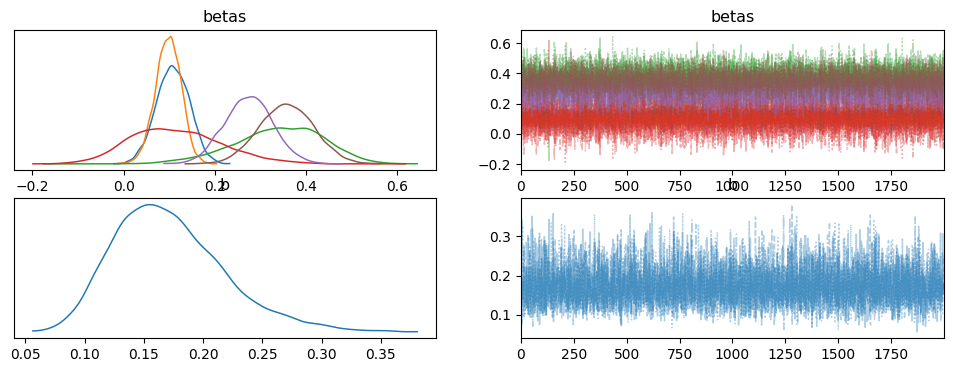

In [ ]:
# Fit the model to get beta estimates
trace_gk = fit_regularized_dirichlet_regression(X_gk_cleaned, gk_probs)

# Extract the mean of the beta posterior samples to use in Algorithm 1
beta_estimates_gk = trace_gk.posterior['betas'].mean(axis=(0,1)).values

# trace_gk
az.plot_trace(trace_gk, combined=True)

# Summary with R-hat, ESS, mean, sd, etc.
summary = az.summary(trace_gk, var_names=["betas"], round_to=2)
summary

In [ ]:
X_gk_cleaned_2 = X_gk_cleaned[[
    'value', 'selected_by_percent_1_ewm', 'selected_by_percent_5_ewm', 'transfers_in_log', 'transfers_out_log'
    ]]

Fitting Regularized Dirichlet model (Sparsity Strength: 0.1)...


Initializing NUTS using adapt_full...
/home/ilyandho/.local/share/mamba/envs/pycaret/lib/python3.10/site-packages/pymc/step_methods/hmc/quadpotential.py:760: UserWarning: QuadPotentialFullAdapt is an experimental feature
  warnings.warn("QuadPotentialFullAdapt is an experimental feature")
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b, betas]


Output()

Sampling 4 chains for 3_000 tune and 2_000 draw iterations (12_000 + 8_000 draws total) took 53 seconds.


✅ Regularized model fitting complete.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
betas[0],0.10,0.04,0.03,0.16,0.0,0.0,7297.50,5710.41,1.0
betas[1],0.29,0.10,0.09,0.47,0.0,0.0,7384.43,5478.15,1.0
betas[2],0.15,0.11,-0.02,0.36,0.0,0.0,7389.34,5662.31,1.0
betas[3],0.31,0.05,0.21,0.41,0.0,0.0,7497.42,5452.00,1.0
betas[4],0.35,0.06,0.23,0.46,0.0,0.0,7565.74,5522.45,1.0


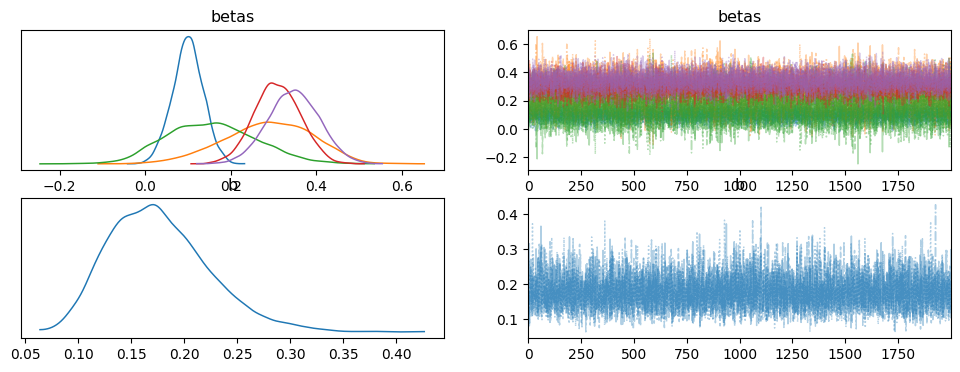

In [ ]:
# Fit the model to get beta estimates
trace_gk = fit_regularized_dirichlet_regression(X_gk_cleaned_2, gk_probs)

# Extract the mean of the beta posterior samples to use in Algorithm 1
beta_estimates_gk = trace_gk.posterior['betas'].mean(axis=(0,1)).values

# trace_gk
az.plot_trace(trace_gk, combined=True)

# Summary with R-hat, ESS, mean, sd, etc.
summary = az.summary(trace_gk, var_names=["betas"], round_to=2)
summary

### DEF


Fitting Regularized Dirichlet model (Sparsity Strength: 0.1)...


Initializing NUTS using adapt_full...
/home/ilyandho/.local/share/mamba/envs/pycaret/lib/python3.10/site-packages/pymc/step_methods/hmc/quadpotential.py:760: UserWarning: QuadPotentialFullAdapt is an experimental feature
  warnings.warn("QuadPotentialFullAdapt is an experimental feature")
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b, betas]


Output()

Sampling 4 chains for 3_000 tune and 2_000 draw iterations (12_000 + 8_000 draws total) took 567 seconds.


✅ Regularized model fitting complete.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
betas[0],-0.01,0.03,-0.06,0.05,0.0,0.0,8969.74,5727.66,1.0
betas[1],-0.07,0.04,-0.14,-0.01,0.0,0.0,8297.53,5959.14,1.0
betas[2],0.03,0.03,-0.02,0.08,0.0,0.0,8975.78,6088.03,1.0
betas[3],0.04,0.02,0.01,0.07,0.0,0.0,8602.13,5877.78,1.0
betas[4],0.04,0.02,0.01,0.07,0.0,0.0,8536.36,6225.81,1.0
betas[5],0.04,0.02,0.00,0.07,0.0,0.0,8610.33,5812.42,1.0
betas[6],-0.02,0.03,-0.08,0.04,0.0,0.0,8013.12,5715.19,1.0
betas[7],-0.07,0.08,-0.22,0.06,0.0,0.0,6767.66,4556.50,1.0
betas[8],-0.05,0.03,-0.10,0.01,0.0,0.0,7655.41,5911.96,1.0
betas[9],-0.03,0.03,-0.10,0.03,0.0,0.0,8142.77,5820.88,1.0


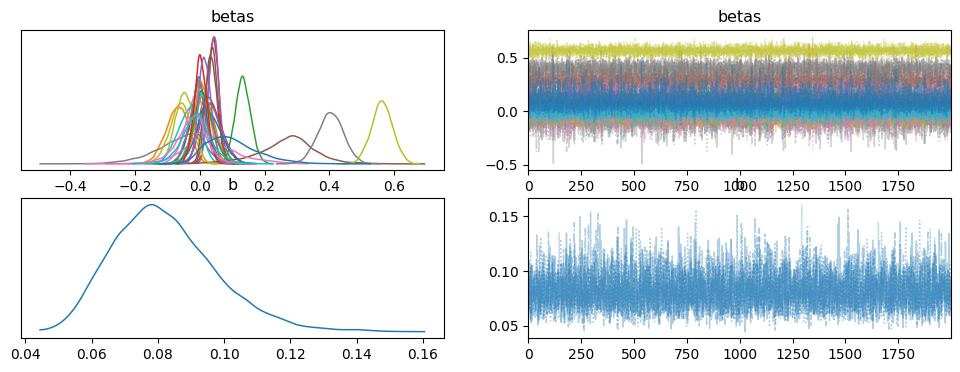

In [ ]:
# Fit the model to get beta estimates
trace_def = fit_regularized_dirichlet_regression(X_def, def_probs)

# Extract the mean of the beta posterior samples to use in Algorithm 1
beta_estimates_def = trace_def.posterior['betas'].mean(axis=(0,1)).values

# trace_def
az.plot_trace(trace_def, combined=True)

# Summary with R-hat, ESS, mean, sd, etc.
summary = az.summary(trace_def, var_names=["betas"], round_to=2)
summary

In [ ]:
# List of indices to remove based on the Lasso analysis
# noise_indices = [0, 2, 3, 4, 5, 6, 8, 9, 10, 11, 13, 14, 16, 17, 20, 21, 22, 23, 24, 25, 26, 29]
feats_def = X_def.columns.tolist()

# 2. Filter for means greater than 0.03
# We use .index to get the 'betas[0]', 'betas[1]' labels
significant_beta_labels = summary[abs(summary['mean']) > 0.05].index

# 3. Extract just the integer indices (if you need them for slicing X_def)
# This splits 'betas[25]' to get '25'
significant_indices = [int(label.split('[')[1].split(']')[0]) for label in significant_beta_labels]
feats_def_cleaned = [feats_def[i] for i in significant_indices]

# Option 1: Drop by index position (safest if you don't have column names handy)
X_def_cleaned = X_def[feats_def_cleaned].copy()

# After dropping, your new feature count should be 57 (67 - 10)
print(f"New feature count: {X_def_cleaned.shape[1]}")
X_def_cleaned.columns


New feature count: 8


Index(['ownership_change_1_ewm', 'pts_bps_5_ewm', 'percentage_net_transfers',
       'selected_by_percent_1_ewm', 'expected_goals_conceded_5_ewm',
       'transfers_in_log', 'transfers_out_log', 'points1_times_transfers'],
      dtype='object')

Initializing NUTS using adapt_full...


Fitting Regularized Dirichlet model (Sparsity Strength: 0.1)...


/home/ilyandho/.local/share/mamba/envs/pycaret/lib/python3.10/site-packages/pymc/step_methods/hmc/quadpotential.py:760: UserWarning: QuadPotentialFullAdapt is an experimental feature
  warnings.warn("QuadPotentialFullAdapt is an experimental feature")
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b, betas]


Output()

Sampling 4 chains for 3_000 tune and 2_000 draw iterations (12_000 + 8_000 draws total) took 105 seconds.


✅ Regularized model fitting complete.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
betas[0],-0.02,0.01,-0.03,-0.00,0.0,0.0,8473.98,5576.09,1.0
betas[1],-0.14,0.08,-0.29,0.02,0.0,0.0,8700.06,5609.41,1.0
betas[2],0.11,0.01,0.09,0.12,0.0,0.0,8525.06,5482.72,1.0
betas[3],0.32,0.01,0.30,0.34,0.0,0.0,8783.44,5418.56,1.0
betas[4],-0.06,0.02,-0.09,-0.03,0.0,0.0,9610.17,5556.74,1.0
betas[5],0.40,0.04,0.33,0.47,0.0,0.0,9255.18,6578.70,1.0
betas[6],0.58,0.03,0.53,0.63,0.0,0.0,8989.89,5361.13,1.0
betas[7],0.12,0.09,-0.03,0.29,0.0,0.0,8700.67,5767.77,1.0


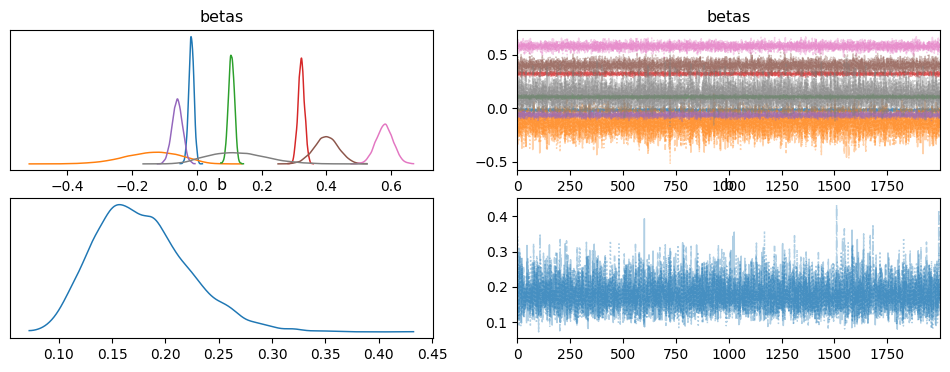

In [ ]:
# Fit the model to get beta estimates
trace_def = fit_regularized_dirichlet_regression(X_def_cleaned, def_probs)

# Extract the mean of the beta posterior samples to use in Algorithm 1
beta_estimates_def = trace_def.posterior['betas'].mean(axis=(0,1)).values

# trace_def
az.plot_trace(trace_def, combined=True)

# Summary with R-hat, ESS, mean, sd, etc.
summary = az.summary(trace_def, var_names=["betas"], round_to=2)
summary

In [ ]:
significant_beta_labels_2 = summary[abs(summary['mean']) > 0.1].index

# 3. Extract just the integer indices (if you need them for slicing X_def)
# This splits 'betas[25]' to get '25'
significant_indices_2 = [int(label.split('[')[1].split(']')[0]) for label in significant_beta_labels_2]
feats_def_cleaned_2 = [feats_def_cleaned[i] for i in significant_indices_2]

# Option 1: Drop by index position (safest if you don't have column names handy)
X_def_cleaned_2 = X_def_cleaned[feats_def_cleaned_2].copy()

# After dropping, your new feature count should be 57 (67 - 10)
print(f"New feature count: {X_def_cleaned_2.shape[1]}")
X_def_cleaned.columns

New feature count: 6


Index(['ownership_change_1_ewm', 'pts_bps_5_ewm', 'percentage_net_transfers',
       'selected_by_percent_1_ewm', 'expected_goals_conceded_5_ewm',
       'transfers_in_log', 'transfers_out_log', 'points1_times_transfers'],
      dtype='object')

Fitting Regularized Dirichlet model (Sparsity Strength: 0.1)...


Initializing NUTS using adapt_full...
/home/ilyandho/.local/share/mamba/envs/pycaret/lib/python3.10/site-packages/pymc/step_methods/hmc/quadpotential.py:760: UserWarning: QuadPotentialFullAdapt is an experimental feature
  warnings.warn("QuadPotentialFullAdapt is an experimental feature")
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b, betas]


Output()

Sampling 4 chains for 3_000 tune and 2_000 draw iterations (12_000 + 8_000 draws total) took 86 seconds.


✅ Regularized model fitting complete.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
betas[0],-0.14,0.09,-0.30,0.02,0.0,0.0,7724.33,5436.19,1.0
betas[1],0.12,0.01,0.11,0.13,0.0,0.0,7813.35,5706.14,1.0
betas[2],0.31,0.01,0.30,0.33,0.0,0.0,8069.47,5811.53,1.0
betas[3],0.37,0.04,0.31,0.45,0.0,0.0,8192.07,6003.70,1.0
betas[4],0.59,0.03,0.54,0.64,0.0,0.0,7822.26,5881.87,1.0
betas[5],0.14,0.09,-0.02,0.32,0.0,0.0,7746.06,5399.86,1.0


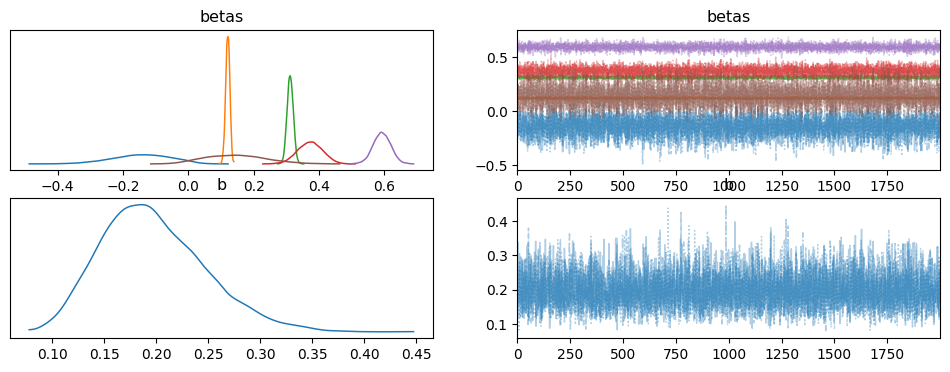

In [ ]:
# Fit the model to get beta estimates
trace_def = fit_regularized_dirichlet_regression(X_def_cleaned_2, def_probs)

# Extract the mean of the beta posterior samples to use in Algorithm 1
beta_estimates_def = trace_def.posterior['betas'].mean(axis=(0,1)).values

# trace_def
az.plot_trace(trace_def, combined=True)

# Summary with R-hat, ESS, mean, sd, etc.
summary = az.summary(trace_def, var_names=["betas"], round_to=2)
summary

### MID


Initializing NUTS using adapt_full...


Fitting Regularized Dirichlet model (Sparsity Strength: 0.1)...


/home/ilyandho/.local/share/mamba/envs/pycaret/lib/python3.10/site-packages/pymc/step_methods/hmc/quadpotential.py:760: UserWarning: QuadPotentialFullAdapt is an experimental feature
  warnings.warn("QuadPotentialFullAdapt is an experimental feature")
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b, betas]


Output()

Sampling 4 chains for 3_000 tune and 2_000 draw iterations (12_000 + 8_000 draws total) took 317 seconds.


✅ Regularized model fitting complete.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
betas[0],0.03,0.01,0.01,0.06,0.0,0.0,10872.61,6241.23,1.0
betas[1],-0.00,0.02,-0.03,0.03,0.0,0.0,10407.38,6355.09,1.0
betas[2],0.03,0.02,-0.00,0.06,0.0,0.0,9534.43,6155.74,1.0
betas[3],0.13,0.01,0.11,0.15,0.0,0.0,10413.18,6115.53,1.0
betas[4],0.02,0.01,0.00,0.04,0.0,0.0,10565.82,5654.69,1.0
betas[5],0.03,0.01,0.00,0.05,0.0,0.0,11982.04,6271.29,1.0
betas[6],0.00,0.02,-0.03,0.04,0.0,0.0,10836.12,5677.91,1.0
betas[7],-0.33,0.09,-0.50,-0.16,0.0,0.0,11108.98,5392.77,1.0
betas[8],-0.04,0.02,-0.07,-0.01,0.0,0.0,10750.55,5913.11,1.0
betas[9],-0.01,0.03,-0.06,0.04,0.0,0.0,10964.32,6242.68,1.0


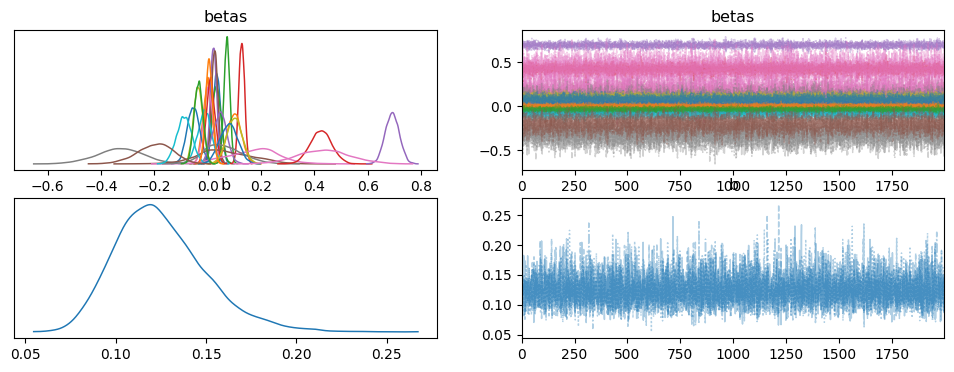

In [ ]:
# Fit the model to get beta estimates
trace_mid = fit_regularized_dirichlet_regression(X_mid, mid_probs)

# Extract the mean of the beta posterior samples to use in Algorithm 1
beta_estimates_mid = trace_mid.posterior['betas'].mean(axis=(0,1)).values

# trace_mid
az.plot_trace(trace_mid, combined=True)

# Summary with R-hat, ESS, mean, sd, etc.
summary = az.summary(trace_mid, var_names=["betas"], round_to=2)
summary

In [ ]:
# List of indices to remove based on the Lasso analysis
# noise_indices = [0, 2, 3, 4, 5, 6, 8, 9, 10, 11, 13, 14, 16, 17, 20, 21, 22, 23, 24, 25, 26, 29]
feats_mid = X_mid.columns.tolist()

# 2. Filter for means greater than 0.03
# We use .index to get the 'betas[0]', 'betas[1]' labels
significant_beta_labels = summary[abs(summary['mean']) > 0.09].index

# 3. Extract just the integer indices (if you need them for slicing X_def)
# This splits 'betas[25]' to get '25'
significant_indices = [int(label.split('[')[1].split(']')[0]) for label in significant_beta_labels]
feats_mid_cleaned = [feats_mid[i] for i in significant_indices]

# Option 1: Drop by index position (safest if you don't have column names handy)
X_mid_cleaned = X_mid[feats_mid_cleaned].copy()

# After dropping, your new feature count should be 57 (67 - 10)
print(f"New feature count: {X_mid_cleaned.shape[1]}")

X_mid_cleaned.columns

New feature count: 9


Index(['value', 'pts_bps_5_ewm', 'minutes_5_ewm', 'selected_by_percent_5_ewm',
       'npxG_1_ewm', 'transfers_in_log', 'transfers_out_log',
       'npxg_times_transfers', 'points1_times_transfers'],
      dtype='object')

Fitting Regularized Dirichlet model (Sparsity Strength: 0.1)...


Initializing NUTS using adapt_full...
/home/ilyandho/.local/share/mamba/envs/pycaret/lib/python3.10/site-packages/pymc/step_methods/hmc/quadpotential.py:760: UserWarning: QuadPotentialFullAdapt is an experimental feature
  warnings.warn("QuadPotentialFullAdapt is an experimental feature")
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b, betas]


Output()

Sampling 4 chains for 3_000 tune and 2_000 draw iterations (12_000 + 8_000 draws total) took 110 seconds.


✅ Regularized model fitting complete.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
betas[0],0.16,0.01,0.14,0.18,0.0,0.0,11597.24,6247.90,1.0
betas[1],-0.50,0.07,-0.63,-0.37,0.0,0.0,10165.45,6144.88,1.0
betas[2],0.03,0.02,-0.00,0.06,0.0,0.0,10422.05,6110.40,1.0
betas[3],0.22,0.01,0.21,0.24,0.0,0.0,10060.09,5957.20,1.0
betas[4],0.01,0.01,-0.01,0.03,0.0,0.0,10384.35,5762.20,1.0
betas[5],0.47,0.04,0.41,0.54,0.0,0.0,10899.38,6367.80,1.0
betas[6],0.61,0.02,0.57,0.66,0.0,0.0,10757.11,5652.57,1.0
betas[7],-0.05,0.02,-0.09,-0.02,0.0,0.0,10171.29,5779.95,1.0
betas[8],0.56,0.08,0.42,0.71,0.0,0.0,10246.40,6096.50,1.0


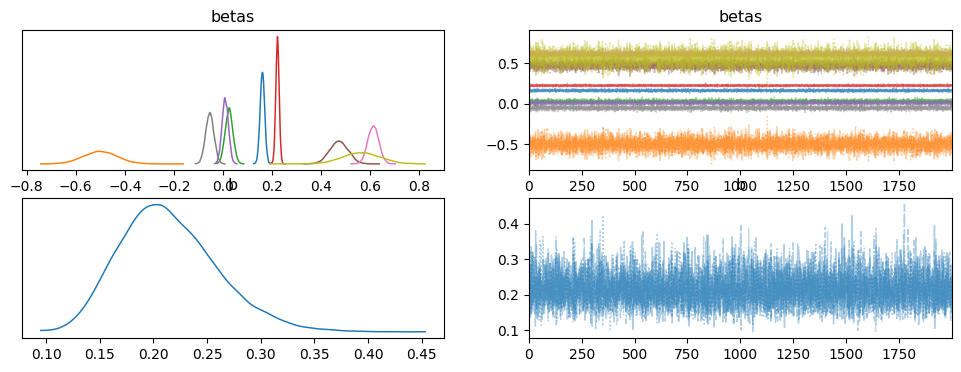

In [ ]:
# Fit the model to get beta estimates
trace_mid = fit_regularized_dirichlet_regression(X_mid_cleaned, mid_probs)

# Extract the mean of the beta posterior samples to use in Algorithm 1
beta_estimates_mid = trace_mid.posterior['betas'].mean(axis=(0,1)).values

# trace_mid
az.plot_trace(trace_mid, combined=True)

# Summary with R-hat, ESS, mean, sd, etc.
summary = az.summary(trace_mid, var_names=["betas"], round_to=2)
summary

In [ ]:
X_mid_cleaned_2 = X_mid_cleaned[[
            'value', 'pts_bps_5_ewm','selected_by_percent_5_ewm', 'transfers_in_log', 'transfers_out_log', 'npxg_times_transfers', 'points1_times_transfers'
                ]]

Fitting Regularized Dirichlet model (Sparsity Strength: 0.1)...


Initializing NUTS using adapt_full...
/home/ilyandho/.local/share/mamba/envs/pycaret/lib/python3.10/site-packages/pymc/step_methods/hmc/quadpotential.py:760: UserWarning: QuadPotentialFullAdapt is an experimental feature
  warnings.warn("QuadPotentialFullAdapt is an experimental feature")
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b, betas]


Output()

Sampling 4 chains for 3_000 tune and 2_000 draw iterations (12_000 + 8_000 draws total) took 103 seconds.


✅ Regularized model fitting complete.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
betas[0],0.16,0.01,0.14,0.18,0.0,0.0,11630.78,5913.79,1.0
betas[1],-0.47,0.06,-0.58,-0.34,0.0,0.0,12748.55,5846.25,1.0
betas[2],0.22,0.01,0.21,0.24,0.0,0.0,10572.00,5488.96,1.0
betas[3],0.49,0.04,0.42,0.55,0.0,0.0,11144.27,5815.36,1.0
betas[4],0.62,0.02,0.57,0.66,0.0,0.0,10854.47,5631.48,1.0
betas[5],-0.04,0.01,-0.07,-0.02,0.0,0.0,11464.90,5543.96,1.0
betas[6],0.53,0.07,0.40,0.67,0.0,0.0,12597.35,6305.26,1.0


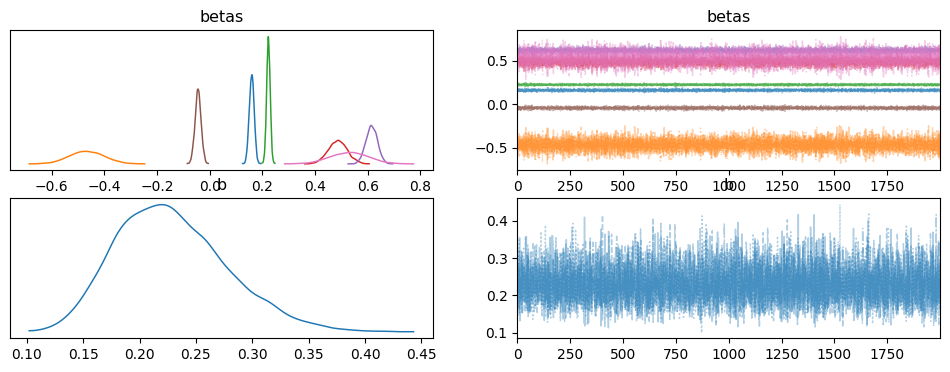

In [ ]:
# Fit the model to get beta estimates
trace_mid = fit_regularized_dirichlet_regression(X_mid_cleaned_2, mid_probs)

# Extract the mean of the beta posterior samples to use in Algorithm 1
beta_estimates_mid = trace_mid.posterior['betas'].mean(axis=(0,1)).values

# trace_mid
az.plot_trace(trace_mid, combined=True)

# Summary with R-hat, ESS, mean, sd, etc.
summary = az.summary(trace_mid, var_names=["betas"], round_to=2)
summary

### FWD


Fitting Regularized Dirichlet model (Sparsity Strength: 0.1)...


Initializing NUTS using adapt_full...
/home/ilyandho/.local/share/mamba/envs/pycaret/lib/python3.10/site-packages/pymc/step_methods/hmc/quadpotential.py:760: UserWarning: QuadPotentialFullAdapt is an experimental feature
  warnings.warn("QuadPotentialFullAdapt is an experimental feature")
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b, betas]


Output()

Sampling 4 chains for 3_000 tune and 2_000 draw iterations (12_000 + 8_000 draws total) took 414 seconds.


✅ Regularized model fitting complete.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
betas[0],0.05,0.05,-0.04,0.14,0.0,0.0,13143.17,5526.87,1.0
betas[1],0.04,0.06,-0.06,0.15,0.0,0.0,13014.79,5508.14,1.0
betas[2],0.04,0.04,-0.03,0.12,0.0,0.0,10824.02,5207.70,1.0
betas[3],-0.02,0.04,-0.09,0.05,0.0,0.0,14099.69,5389.00,1.0
betas[4],0.01,0.03,-0.03,0.07,0.0,0.0,15193.73,4816.69,1.0
betas[5],0.02,0.03,-0.03,0.07,0.0,0.0,14715.61,5661.01,1.0
betas[6],-0.01,0.04,-0.08,0.06,0.0,0.0,13807.63,4620.03,1.0
betas[7],-0.03,0.08,-0.18,0.11,0.0,0.0,10107.85,5042.63,1.0
betas[8],-0.03,0.04,-0.10,0.04,0.0,0.0,12868.09,5746.18,1.0
betas[9],0.05,0.06,-0.05,0.16,0.0,0.0,11922.64,4991.88,1.0


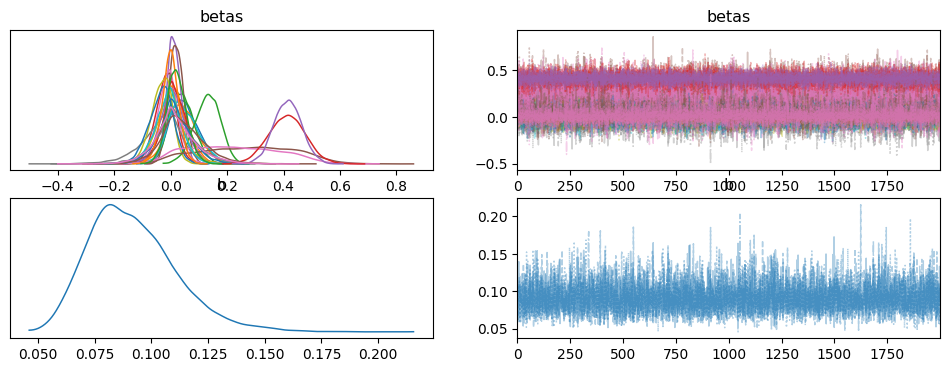

In [ ]:
# Fit the model to get beta estimates
trace_fwd = fit_regularized_dirichlet_regression(X_fwd, fwd_probs)

# Extract the mean of the beta posterior samples to use in Algorithm 1
beta_estimates_fwd = trace_fwd.posterior['betas'].mean(axis=(0,1)).values

# trace_fwd
az.plot_trace(trace_fwd, combined=True)

# Summary with R-hat, ESS, mean, sd, etc.
summary = az.summary(trace_fwd, var_names=["betas"], round_to=2)
summary

In [ ]:
# List of indices to remove based on the Lasso analysis
# noise_indices = [0, 2, 3, 4, 5, 6, 8, 9, 10, 11, 13, 14, 16, 17, 20, 21, 22, 23, 24, 25, 26, 29]
feats_fwd = X_fwd.columns.tolist()

# 2. Filter for means greater than 0.03
# We use .index to get the 'betas[0]', 'betas[1]' labels
significant_beta_labels = summary[abs(summary['mean']) > 0.04].index

# 3. Extract just the integer indices (if you need them for slicing X_def)
# This splits 'betas[25]' to get '25'
significant_indices = [int(label.split('[')[1].split(']')[0]) for label in significant_beta_labels]
feats_fwd_cleaned = [feats_fwd[i] for i in significant_indices]

# Option 1: Drop by index position (safest if you don't have column names handy)
X_fwd_cleaned = X_fwd[feats_fwd_cleaned].copy()

# After dropping, your new feature count should be 57 (67 - 10)
print(f"New feature count: {X_fwd_cleaned.shape[1]}")
X_fwd_cleaned.columns


New feature count: 7


Index(['ownership_change', 'xP_5_ewm', 'percentage_net_transfers',
       'selected_by_percent_1_ewm', 'selected_by_percent_5_ewm',
       'transfers_in_log', 'transfers_out_log'],
      dtype='object')

Fitting Regularized Dirichlet model (Sparsity Strength: 0.1)...


Initializing NUTS using adapt_full...
/home/ilyandho/.local/share/mamba/envs/pycaret/lib/python3.10/site-packages/pymc/step_methods/hmc/quadpotential.py:760: UserWarning: QuadPotentialFullAdapt is an experimental feature
  warnings.warn("QuadPotentialFullAdapt is an experimental feature")
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b, betas]


Output()

Sampling 4 chains for 3_000 tune and 2_000 draw iterations (12_000 + 8_000 draws total) took 60 seconds.


✅ Regularized model fitting complete.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
betas[0],0.01,0.04,-0.07,0.09,0.0,0.0,10480.50,5673.03,1.0
betas[1],0.06,0.03,-0.00,0.12,0.0,0.0,10490.03,5439.42,1.0
betas[2],0.13,0.04,0.05,0.21,0.0,0.0,11123.73,5897.50,1.0
betas[3],0.42,0.07,0.29,0.55,0.0,0.0,11048.54,5486.90,1.0
betas[4],0.07,0.07,-0.06,0.21,0.0,0.0,11001.54,5336.42,1.0
betas[5],0.45,0.05,0.36,0.53,0.0,0.0,11292.87,5933.61,1.0
betas[6],0.42,0.04,0.34,0.49,0.0,0.0,10640.59,5866.75,1.0


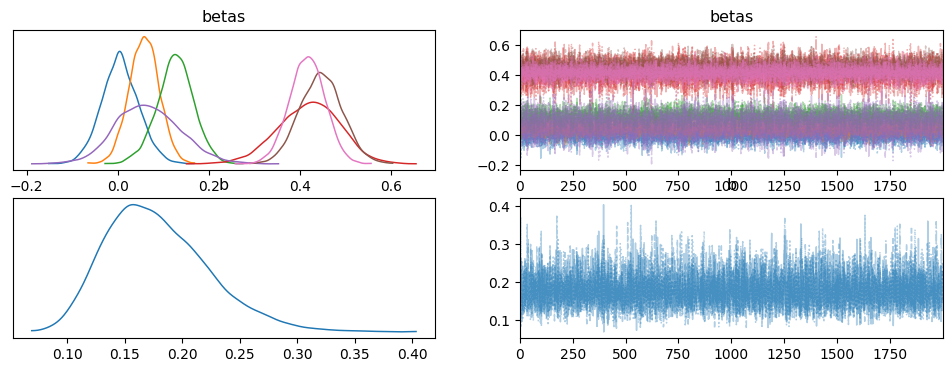

In [ ]:
# Fit the model to get beta estimates
trace_fwd = fit_regularized_dirichlet_regression(X_fwd_cleaned, fwd_probs)

# Extract the mean of the beta posterior samples to use in Algorithm 1
beta_estimates_fwd = trace_fwd.posterior['betas'].mean(axis=(0,1)).values

# trace_fwd
az.plot_trace(trace_fwd, combined=True)

# Summary with R-hat, ESS, mean, sd, etc.
summary = az.summary(trace_fwd, var_names=["betas"], round_to=2)
summary

In [ ]:
X_fwd_cleaned_2 = X_fwd_cleaned[[
                'ownership_change', 'xP_5_ewm', 'percentage_net_transfers', 'selected_by_percent_5_ewm', 'transfers_in_log'
                ]]



Initializing NUTS using adapt_full...


Fitting Regularized Dirichlet model (Sparsity Strength: 0.1)...


/home/ilyandho/.local/share/mamba/envs/pycaret/lib/python3.10/site-packages/pymc/step_methods/hmc/quadpotential.py:760: UserWarning: QuadPotentialFullAdapt is an experimental feature
  warnings.warn("QuadPotentialFullAdapt is an experimental feature")
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b, betas]


Output()

Sampling 4 chains for 3_000 tune and 2_000 draw iterations (12_000 + 8_000 draws total) took 38 seconds.


✅ Regularized model fitting complete.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
betas[0],-0.11,0.05,-0.19,-0.02,0.0,0.0,8410.63,6276.19,1.0
betas[1],0.03,0.03,-0.03,0.09,0.0,0.0,8743.19,5665.72,1.0
betas[2],0.14,0.04,0.06,0.23,0.0,0.0,8659.26,5879.32,1.0
betas[3],0.52,0.02,0.48,0.56,0.0,0.0,8782.31,6324.06,1.0
betas[4],0.66,0.04,0.59,0.73,0.0,0.0,8838.34,5759.43,1.0


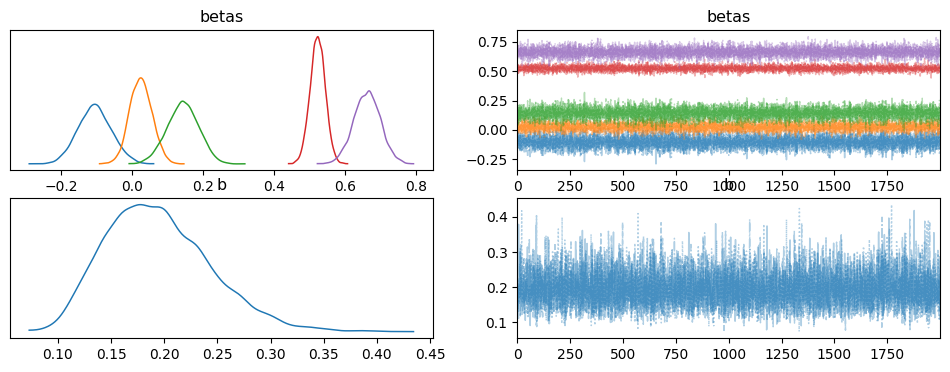

In [ ]:
# Fit the model to get beta estimates
trace_fwd = fit_regularized_dirichlet_regression(X_fwd_cleaned_2, fwd_probs)

# Extract the mean of the beta posterior samples to use in Algorithm 1
beta_estimates_fwd = trace_fwd.posterior['betas'].mean(axis=(0,1)).values

# trace_fwd
az.plot_trace(trace_fwd, combined=True)

# Summary with R-hat, ESS, mean, sd, etc.
summary = az.summary(trace_fwd, var_names=["betas"], round_to=2)
summary

In [ ]:
X_gk_cleaned_2.columns

Index(['value', 'selected_by_percent_1_ewm', 'selected_by_percent_5_ewm',
       'transfers_in_log', 'transfers_out_log'],
      dtype='object')

: 

In [ ]:
X_def_cleaned_2.columns

Index(['pts_bps_5_ewm', 'percentage_net_transfers',
       'selected_by_percent_1_ewm', 'transfers_in_log', 'transfers_out_log',
       'points1_times_transfers'],
      dtype='object')

In [ ]:
X_mid_cleaned_2.columns

Index(['value', 'pts_bps_5_ewm', 'selected_by_percent_5_ewm',
       'transfers_in_log', 'transfers_out_log', 'npxg_times_transfers',
       'points1_times_transfers'],
      dtype='object')

In [ ]:
X_fwd_cleaned_2.columns

Index(['ownership_change', 'xP_5_ewm', 'percentage_net_transfers',
       'selected_by_percent_5_ewm', 'transfers_in_log'],
      dtype='object')

## Save


In [ ]:
joblib.dump(trace_gk, './betas/trace_gk')
joblib.dump(trace_def, './betas/trace_def')
joblib.dump(trace_mid, './betas/trace_mid')
joblib.dump(trace_fwd, './betas/trace_fwd')

['./betas/trace_fwd']

In [ ]:
 # Convert to pandas DataFrame
pd.DataFrame({
    "gk": beta_estimates_gk
}).to_csv('./betas/gk_betas.csv', index=False)

pd.DataFrame({
    "def": beta_estimates_def
}).to_csv('./betas/def_betas.csv', index=False)

pd.DataFrame({
    "mid": beta_estimates_mid
}).to_csv('./betas/mid_betas.csv', index=False)

pd.DataFrame({
    "fwd": beta_estimates_fwd
}).to_csv('./betas/fwd_betas.csv', index=False)